# plot points

内部 source 点数: 4504
边界点数: 100
patch 数: 49
evaluation 点数: 4504


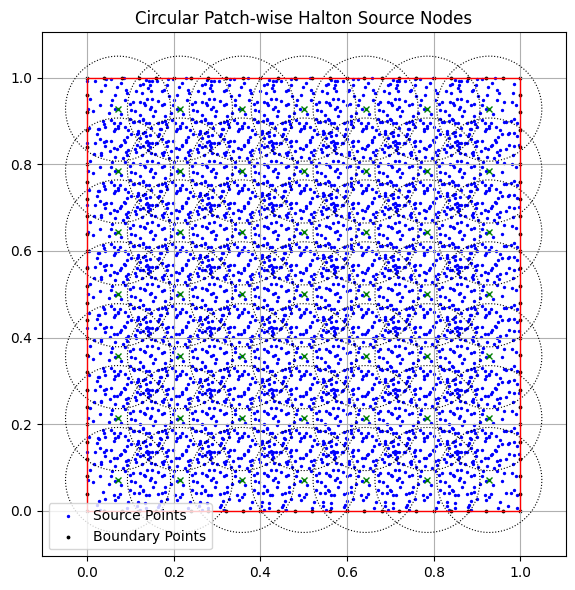

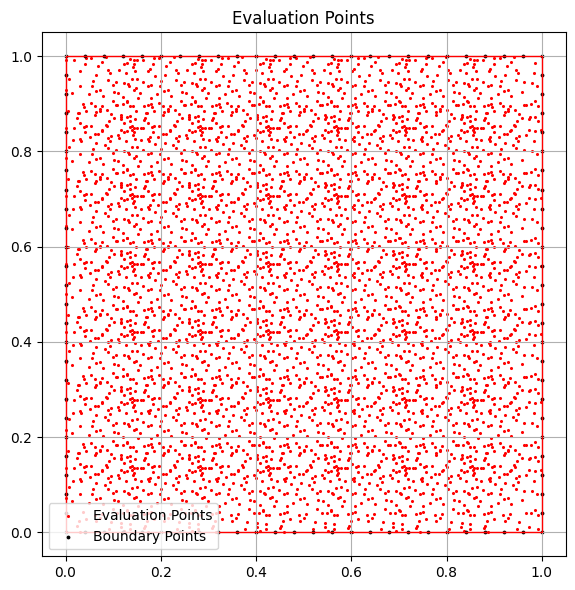

In [1]:

from matplotlib.pylab import eigvals
import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial import cKDTree, distance
from scipy.linalg import solve, lstsq,lu_factor, lu_solve
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, splu
import matplotlib.pyplot as plt
from math import pi
import math

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_square(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap=0.2,
    mode="c-rbf-pum"
):
    """
    Square domain (0,1)^2
    Circular patches + patch-wise Halton nodes
    """

    x_min, x_max = 0.0, 1.0
    y_min, y_max = 0.0, 1.0

    # =====================================================
    # patch centers
    # =====================================================
    H = (x_max - x_min) / N_patch_grid

    x_centers = np.linspace(
        x_min + H / 2,
        x_max - H / 2,
        N_patch_grid
    )
    y_centers = np.linspace(
        y_min + H / 2,
        y_max - H / 2,
        N_patch_grid
    )

    Xc, Yc = np.meshgrid(x_centers, y_centers)
    centers = np.column_stack([Xc.ravel(), Yc.ravel()])

    R_patch = (1 + overlap) * np.sqrt(2) * H / 2
    R_all = R_patch * np.ones(centers.shape[0])

    ptch = {
        "C": centers,
        "R": R_all
    }

    # =====================================================
    # reference Halton disc
    # =====================================================
    Hq = halton_sequence(N_local_per_patch, 2)

    theta = 2 * np.pi * Hq[:, 0]
    r = np.sqrt(Hq[:, 1]) * R_patch

    X_ref = np.column_stack([
        r * np.cos(theta),
        r * np.sin(theta)
    ])

    # =====================================================
    # patch-wise source nodes
    # =====================================================
    X_inner_list = []

    for c in centers:
        X_local = X_ref + c

        mask = (
            (X_local[:, 0] >= x_min) &
            (X_local[:, 0] <= x_max) &
            (X_local[:, 1] >= y_min) &
            (X_local[:, 1] <= y_max)
        )

        X_inner_list.append(X_local[mask])

    X_inner = np.vstack(X_inner_list)

    # =====================================================
    # evaluation points
    # =====================================================
    if mode == "c-rbf-pum":
        grid_eval = X_inner.copy()

    elif mode == "ls-rbf-pum":
        n_eval = int(np.sqrt(X_inner.shape[0]) * 2)
        xe = np.linspace(x_min, x_max, n_eval)
        ye = np.linspace(y_min, y_max, n_eval)
        Xe, Ye = np.meshgrid(xe, ye)
        grid_eval = np.column_stack([Xe.ravel(), Ye.ravel()])

    else:
        raise ValueError("Unknown mode")

    # =====================================================
    # boundary points
    # =====================================================
    n_side = N_boundary // 4
    rem = N_boundary % 4
    counts = [n_side] * 4
    for i in range(rem):
        counts[i] += 1

    xb = np.linspace(x_min, x_max, counts[0], endpoint=False)
    bottom = np.column_stack([xb, y_min * np.ones_like(xb)])

    yr = np.linspace(y_min, y_max, counts[1], endpoint=False)
    right = np.column_stack([x_max * np.ones_like(yr), yr])

    xt = np.linspace(x_max, x_min, counts[2], endpoint=False)
    top = np.column_stack([xt, y_max * np.ones_like(xt)])

    yl = np.linspace(y_max, y_min, counts[3], endpoint=False)
    left = np.column_stack([x_min * np.ones_like(yl), yl])

    X_boundary = np.vstack([bottom, right, top, left])

    boundary_curve = np.array([
        [0, 0],
        [1, 0],
        [1, 1],
        [0, 1],
        [0, 0]
    ])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve


# =========================================================
# 4. Plot
# =========================================================
def plot_generator_points(
    X_inner,
    X_boundary,
    ptch,
    grid_eval,
    boundary_curve
):
    C = ptch["C"]
    R = ptch["R"]
    theta = np.linspace(0, 2 * np.pi, 200)

    # =========================
    # Figure 1
    # =========================
    plt.figure(figsize=(7, 6))
    ax = plt.gca()

    for i in range(C.shape[0]):
        x = C[i, 0] + R[i] * np.cos(theta)
        y = C[i, 1] + R[i] * np.sin(theta)

        ax.plot(x, y, 'k:', linewidth=0.8)
        ax.plot(C[i, 0], C[i, 1], 'gx', markersize=5)

    ax.plot(boundary_curve[:, 0], boundary_curve[:, 1], 'r-', linewidth=1.0)

    ax.scatter(X_inner[:, 0], X_inner[:, 1],
               s=8, c='b', marker='.', label='Source Points')

    ax.scatter(X_boundary[:, 0], X_boundary[:, 1],
               s=12, c='k', marker='.', label='Boundary Points')

    ax.set_aspect('equal')
    ax.set_title('Circular Patch-wise Halton Source Nodes')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()

    # =========================
    # Figure 2
    # =========================
    plt.figure(figsize=(7, 6))
    ax2 = plt.gca()

    ax2.plot(boundary_curve[:, 0], boundary_curve[:, 1], 'r-', linewidth=1.0)

    ax2.scatter(grid_eval[:, 0], grid_eval[:, 1],
                s=6, c='r', marker='.', label='Evaluation Points')

    ax2.scatter(X_boundary[:, 0], X_boundary[:, 1],
                s=12, c='k', marker='.', label='Boundary Points')

    ax2.set_aspect('equal')
    ax2.set_title('Evaluation Points')
    ax2.grid(True)
    ax2.legend()
    plt.tight_layout()

    plt.show()


# =========================================================
# 5. Main
# =========================================================
if __name__ == "__main__":
    N_patch_grid = 7
    N_local_per_patch = 100
    N_boundary = 100
    overlap = 0.2
    mode = "c-rbf-pum"

    X_inner, X_boundary, ptch, grid_eval, boundary_curve = \
        generator_points_square(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            mode
        )

    print("内部 source 点数:", X_inner.shape[0])
    print("边界点数:", X_boundary.shape[0])
    print("patch 数:", ptch["C"].shape[0])
    print("evaluation 点数:", grid_eval.shape[0])

    plot_generator_points(
        X_inner,
        X_boundary,
        ptch,
        grid_eval,
        boundary_curve
    )
    

In [2]:
class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(6.2)**2 * x**2)
        # output = torch.exp(-(0.9225)**2 * x**2) # operator
        output = self.input_layer(x)
        output = torch.sigmoid(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, -np.pi, np.pi)


def laplacian_phi_wrt_y(phi_net, y, X, eps):
    """
    y: tensor (1,2) evalution points, requires_grad = True
    X: tensor (K,2) source points
    Returns: phi_vals (K,1), laplacian_y (K,1), grad_y (K,2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim()==1:
        y = y.unsqueeze(0)   # (1,2)
    K = X.shape[0]
    # compute r_j
    diff = y - X          # (K,2) if y (1,2)
    r = torch.norm(diff, dim=1, keepdim=True)   # (K,1)
    r = r.clamp(min=eps)  # 防止除零

    r.requires_grad_(True)    # 需要对 r 求导
    phi_vals = phi_net(r)     # (K,1)
    # phi_vals = phi_gauss(eps,r) # to check whether the laplace using autograd is correct

    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (K,1)

    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]   # (K,1)

    n = y.shape[1]  # dimension, n = 2 here
    lap_r = d2phi_dr2 + (n-1)/r * dphi_dr   # (K,1),
    # print("relative error between  is",relative_loss(lap_r, laplace_phi_gauss(eps, r)))
    # 一阶向量梯度 wrt y： ∇_y φ = φ'(r) * (y - x)/r
    grad_y = dphi_dr * (diff / r)    # broadcasting (K,2): (grad_y1,grad_y2) 
    phi_vals = phi_vals.detach().cpu().numpy()
    lap_r = lap_r.detach().cpu().numpy()
    grad_y = grad_y.detach().cpu().numpy()
    return phi_vals, lap_r, grad_y

def rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    W_ide = np.zeros((M, K))
    W_lap = np.zeros((M, K))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        f_val = f_func(Yin[:,0:1], Yin[:,1:2],t)
    elif isinstance(f_func, np.ndarray):
        f_val = f_func # (M1,NT)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        g_val = g_func(Yb[:,0:1], Yb[:,1:2],t)
    elif isinstance(g_func, np.ndarray):
        g_val = g_func # (M2,NT)
    else:
        raise ValueError("g_func must be callable or numpy array")
    if callable(u0_func):
        u0 = u0_func(Y[:,0:1], Y[:,1:2])
    elif isinstance(u0_func, np.ndarray):
        u0 = u0_func[:,None] # (M,1)
    else:
        raise ValueError("u0_func must be callable or numpy array")

    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))
        A = np.zeros((K,K))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # print(np.max(np.max(Phi_jj)), np.min(np.min(Phi_jj)))
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## RHS_lap, RHS_ide
        RHS_lap = lap_phi
        RHS_ide = phi_xj
        ## W_ide, W_lap
        A  =  Phi_jj  + reg * np.eye(K) # (K,K)

        w_ide = np.linalg.solve(A,RHS_ide).flatten() # (K,)
        W_ide[i,:] = w_ide
        w_lap = np.linalg.solve(A,RHS_lap).flatten() # (K,)
        W_lap[i,:] = w_lap
        if i < M1 :
            LBDF1[i,idx_local] += (w_ide - tau * w_lap)
            LBDF2[i,idx_local] += (3 * w_ide - 2* tau * w_lap)
        else:
            LBDF1[i,idx_local] += w_ide
            LBDF2[i,idx_local] += w_ide
        LI[i,idx_local] += w_ide
    
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:,1:2] = LI @ alpha_1
        # U[:M1,1:2] = LI[:M1, :] @ alpha_1
        # U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            # alpha_2 = spsolve(LBDF2,RHS)[:,None]
            alpha_2 = LU.solve(RHS)
            U[:,i+1:i+2] = LI @ alpha_2
            alpha_0 = alpha_1
            alpha_1 = alpha_2

    else:
        print("M $\neq$ N. Please use QR.")

        # Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        # UX = np.linalg.solve(R, Q.T @ RHS)
    return U,LBDF1,LBDF2,LI

def poly2D(Z, order):
    K = Z.shape[0]
    Norder = (order+1)*(order+2)//2
    P = np.zeros((K, Norder))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
            idx += 1
    return P

def poly2D_at_point(y, order):
    """Generate column vector of poly basis at single point y (2D)"""
    Norder = (order+1)*(order+2)//2
    p_y = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            p_y[idx,0] = (y[0]**i) * (y[1]**j)
            idx += 1
    return p_y

def laplacian_poly2D(order, y):
    """
    y: (2,) point
    return: column vector (Norder,1) of Laplacian evaluated at y
    """
    Norder = (order+1)*(order+2)//2
    lap = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            val = 0.0
            if i >= 2:
                val += i*(i-1)*y[0]**(i-2) * y[1]**j
            if j >= 2:
                val += j*(j-1)*y[0]**i * y[1]**(j-2)
            lap[idx,0] = val
            idx += 1
    return lap

def rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))

    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    O = np.zeros((Norder,Norder))
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # print(np.max(np.max(Phi_jj)), np.min(np.min(Phi_jj)))
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## AP
        P = poly2D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+3)
        AP[K:,:-Norder] = P.T # (Norder,K)
        AP = AP + reg * np.eye(K+Norder)
        LU = lu_factor(AP)
        ## w_ide, w_lap
        p_y = poly2D_at_point(y, order)  # (Norder,1)
        RHS_ide[:K,0] = phi_xj[:,0]                           # shape (K,)
        RHS_ide[K:,0] = p_y[:,0]
        w_ide = lu_solve(LU, RHS_ide).T # (1,K+Norder)
        # w_ide = np.linalg.solve(AP,RHS_ide).T # (1,K+Norder)
        RHS_lap[:K,0] = lap_phi[:,0]
        RHS_lap[K:,0] = laplacian_poly2D(order, y)[:,0]
        w_lap = lu_solve(LU, RHS_lap).T # (1,K+Noder)
        # w_lap = np.linalg.solve(AP,RHS_lap).T # (1,K+Noder)
        if i < M1 :
            LBDF1[i:i+1,idx_local] += (w_ide[0:1,:K] - tau * w_lap[0:1,:K])
            LBDF2[i:i+1,idx_local] += (3 * w_ide[0:1,:K] - 2* tau * w_lap[0:1,:K])
        else:
            LBDF1[i:i+1,idx_local] += w_ide[0:1,:K]
            LBDF2[i:i+1,idx_local] += w_ide[0:1,:K]
        LI[i:i+1,idx_local] += w_ide[0:1,:K]
        
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)

    # Lh = (3 * LI - LBDF2)/ (2 * tau)
    # eigvals = np.linalg.eigvals(Lh.todense()[1:M1,1:M1])
    # eigvals = np.sort(eigvals)[::-1] 
    # print("eigvals(Lh) =", eigvals)
    # # print("eigvals(Lh) =", S)
    # plt.figure()
    # plt.plot(eigvals.real, eigvals.imag, 'o', markersize=2)
    # plt.axvline(0, color='r')
    # plt.title("Spectrum of Laplacian (PhiNet)")
    # plt.show()

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M $\neq$ N. Please use QR.")
        
    return U,LBDF1,LBDF2,LI


def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

cond(LI) = 1.0000098149718917
cond(LBDF1) = 2409203705499.3145
cond(LBDF2) = 4611960225244.594
(1823, 201) (1823, 201)
p = 4; L infity error in u_rfmfd: 2.660e-02
p = 4; Relative L2 error in u_rfmfd: 5.558e-03


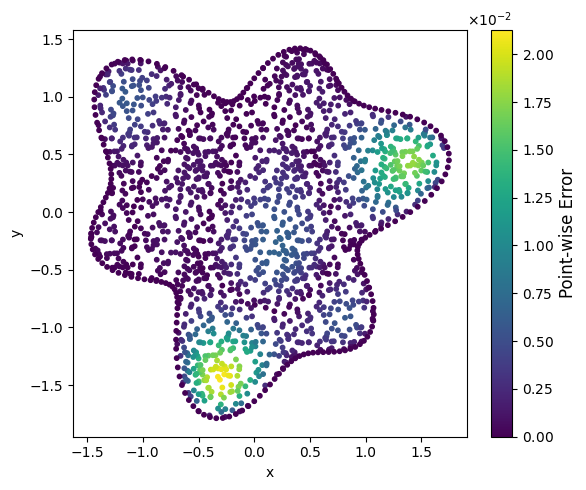

In [ ]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(1, hidden_size, 1).to(device) #
Phi.initi()
Phi = Phi.double()


# # ===========================================================
u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_square(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
M1 = Yin.shape[0]

#####
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

order = 4

K = 60
reg = 1e-12
u_true = u_func(Y[:,0:1], Y[:,1:2],t)

# # ===========================================================
if order == 0:
    U,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
print(u_true.shape,U.shape)
# error = np.abs(U[M1:,:] - u_true[M1:,:])
# print(f' L infity error on bc: {error.max().item():.3e}')

error = np.abs(U - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')

UT = U[:,-1:].toarray().ravel()
u_true_T = u_true[:,-1:].squeeze(-1)

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UT - u_true_T), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'./result/heat_rfmfd_p={order}_200_error.eps', bbox_inches='tight')
plt.show()


# 画收敛阶段图

Run Q=1, N_local_per_patch=15
X.shape 136
cond(LI) = 1.000000927838879
cond(LBDF1) = 28642652.242489748
cond(LBDF2) = 57283991.778171
h = 3.445e-01, L2 error = 9.190e-02, 
Run Q=2, N_local_per_patch=30
X.shape 274
cond(LI) = 1.0000009334205235
cond(LBDF1) = 30698670.19551131
cond(LBDF2) = 61394538.876904875
h = 2.005e-01, L2 error = 7.603e-02, 
Run Q=3, N_local_per_patch=70
X.shape 644
cond(LI) = 1.000002189421124
cond(LBDF1) = 55659887.01424121
cond(LBDF2) = 111307132.43186352
h = 1.438e-01, L2 error = 7.305e-02, 
Run Q=4, N_local_per_patch=100
X.shape 914
cond(LI) = 1.0000033530789598
cond(LBDF1) = 87922202.9683521
cond(LBDF2) = 175815418.25214964
h = 1.257e-01, L2 error = 7.143e-02, 
Run Q=5, N_local_per_patch=145
X.shape 1320
cond(LI) = 1.000009917634116
cond(LBDF1) = 373142683.89405197
cond(LBDF2) = 746104517.1592497
h = 9.395e-02, L2 error = 6.992e-02, 
slope = 0.211400, bias = 0.952527


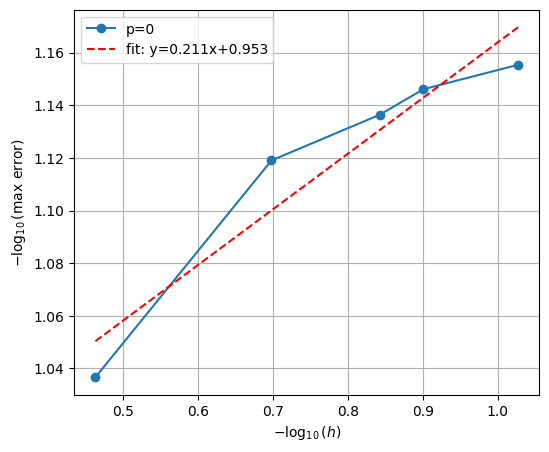

In [3]:
key = 100
np.random.seed(key)

NN = [15,30,70,100,145]
H = np.zeros((5,len(NN)))
E = np.zeros((5,len(NN)))
KK = [20,30,45,60,90]
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 0
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
X.shape 136
cond(LI) = 1.0000009281914002
cond(LBDF1) = 31840774.037173517
cond(LBDF2) = 63679223.61754666
h = 3.445e-01, L2 error = 6.696e-02, 
Run Q=2, N_local_per_patch=30
X.shape 274
cond(LI) = 1.0000009336455502
cond(LBDF1) = 35145856.320711456
cond(LBDF2) = 70286785.81418966
h = 2.005e-01, L2 error = 5.820e-02, 
Run Q=3, N_local_per_patch=65
X.shape 598
cond(LI) = 1.0000026454166802
cond(LBDF1) = 77730743.27228355
cond(LBDF2) = 155440577.52764374
h = 1.551e-01, L2 error = 5.727e-02, 
Run Q=4, N_local_per_patch=100
X.shape 914
cond(LI) = 1.000003352942765
cond(LBDF1) = 97388598.51667972
cond(LBDF2) = 194737549.4561151
h = 1.257e-01, L2 error = 5.707e-02, 
Run Q=5, N_local_per_patch=145
X.shape 1320
cond(LI) = 1.000009917407996
cond(LBDF1) = 416727424.1980315
cond(LBDF2) = 833202740.2766999
h = 9.395e-02, L2 error = 5.636e-02, 
slope = 0.130418, bias = 1.127111


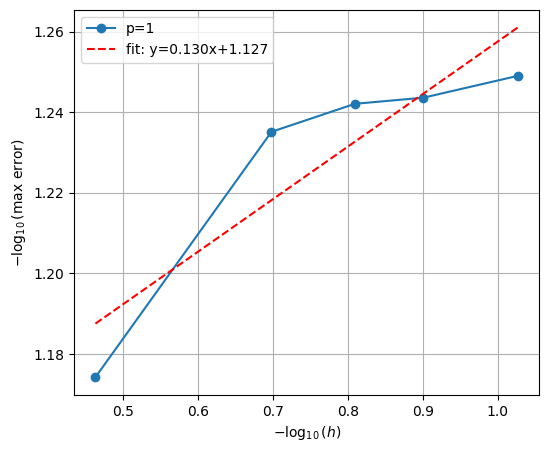

In [4]:

key = 100
np.random.seed(key)


NN = [15,30, 65, 100,145]
KK = [30,40, 50, 70, 110]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 1
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
X.shape 136
cond(LI) = 1.0000009285806712
cond(LBDF1) = 61546345.89052973
cond(LBDF2) = 123074226.1615185
h = 3.445e-01, L2 error = 2.922e-02, 
Run Q=2, N_local_per_patch=30
X.shape 274
cond(LI) = 1.0000009338895441
cond(LBDF1) = 72233481.5922637
cond(LBDF2) = 144428845.04257193
h = 2.005e-01, L2 error = 1.749e-02, 
Run Q=3, N_local_per_patch=65
X.shape 598
cond(LI) = 1.0000026426143918
cond(LBDF1) = 230701847.44695163
cond(LBDF2) = 461055620.50688744
h = 1.551e-01, L2 error = 1.684e-02, 
Run Q=4, N_local_per_patch=100
X.shape 914
cond(LI) = 1.0000033483215227
cond(LBDF1) = 312663583.40010077
cond(LBDF2) = 624633638.1013227
h = 1.257e-01, L2 error = 1.582e-02, 
Run Q=5, N_local_per_patch=145
X.shape 1320
cond(LI) = 1.000009914940125
cond(LBDF1) = 1338648053.1440406
cond(LBDF2) = 2672603993.513519


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


h = 9.395e-02, L2 error = 1.496e-02, 
slope = 0.506904, bias = 1.343100


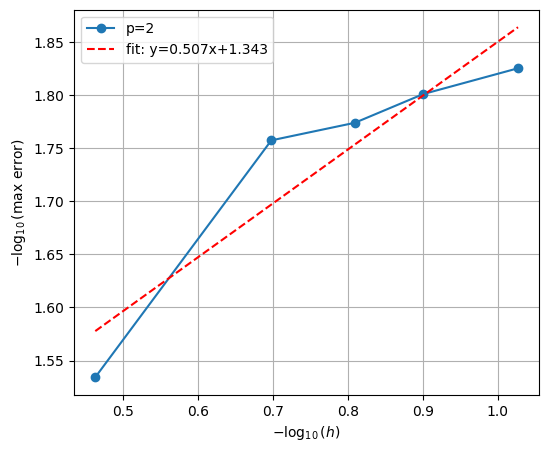

In [5]:
key = 100
np.random.seed(key)

# NN = [30, 100, 120, 140, 160]
# KK = [40, 40, 40, 40,  69]
# RR = [1e-12,1e-12,1e-14,1e-12,0]
NN = [15, 30, 65, 100,145]
KK = [30, 40, 40, 55, 65]

RR = [1e-12,1e-12,1e-12,1e-12,1e-12]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 2
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
X.shape 136
cond(LI) = 1.0000009294832284
cond(LBDF1) = 64516668.40810958
cond(LBDF2) = 129025232.29184695
h = 3.445e-01, L2 error = 1.015e-02, 
Run Q=2, N_local_per_patch=30
X.shape 274
cond(LI) = 1.0000009352770043
cond(LBDF1) = 108541713.50443925
cond(LBDF2) = 217045166.0857735
h = 2.005e-01, L2 error = 8.921e-03, 
Run Q=3, N_local_per_patch=65
X.shape 598
cond(LI) = 1.0000026288961263
cond(LBDF1) = 914325847.8205737
cond(LBDF2) = 1827961517.7693233
h = 1.551e-01, L2 error = 8.377e-03, 
Run Q=4, N_local_per_patch=100
X.shape 914
cond(LI) = 1.0000033233790504
cond(LBDF1) = 1174233369.555138
cond(LBDF2) = 2347263381.787945
h = 1.257e-01, L2 error = 7.564e-03, 
Run Q=5, N_local_per_patch=145
X.shape 1320
cond(LI) = 1.0000098744731774
cond(LBDF1) = 5589252325.826567
cond(LBDF2) = 11170289106.393715


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


h = 9.395e-02, L2 error = 7.126e-03, 
slope = 0.279282, bias = 1.860021


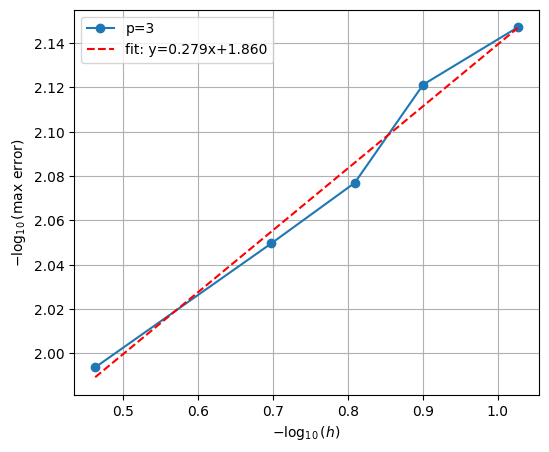

In [6]:
key = 100
np.random.seed(key)

NN = [15, 30, 65, 100,145]
KK = [40, 35, 45, 55, 65]
RR = [1e-12,1e-12,1e-13,1e-13,1e-13]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 3
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
X.shape 136
cond(LI) = 1.0000009328230566
cond(LBDF1) = 108919835.51743641
cond(LBDF2) = 217792121.73031402
h = 3.445e-01, L2 error = 1.388e-02, 
Run Q=2, N_local_per_patch=30
X.shape 274
cond(LI) = 1.000000935999217
cond(LBDF1) = 1440331998.2238173
cond(LBDF2) = 2893382901.657464
h = 2.005e-01, L2 error = 7.912e-03, 
Run Q=3, N_local_per_patch=65
X.shape 598
cond(LI) = 1.0000026140610945
cond(LBDF1) = 35891292683.66496
cond(LBDF2) = 71582468842.09781
h = 1.551e-01, L2 error = 6.740e-03, 
Run Q=4, N_local_per_patch=100
X.shape 914
cond(LI) = 1.000003324082836
cond(LBDF1) = 16912327752.436556
cond(LBDF2) = 33701727885.873085
h = 1.257e-01, L2 error = 5.772e-03, 
Run Q=5, N_local_per_patch=145
X.shape 1320
cond(LI) = 1.0000098696725732
cond(LBDF1) = 50918993737.50277
cond(LBDF2) = 101659799244.53546
h = 9.395e-02, L2 error = 3.843e-03, 
slope = 0.944234, bias = 1.420892


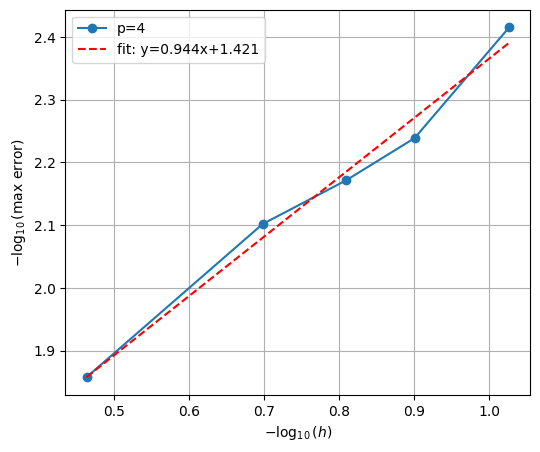

In [7]:
key = 100
np.random.seed(key)

NN = [15, 30, 65, 100,145]
KK = [30, 40, 50, 85, 125]
RR = [1e-12,1e-12,1e-13,1e-13,1e-13]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 4
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


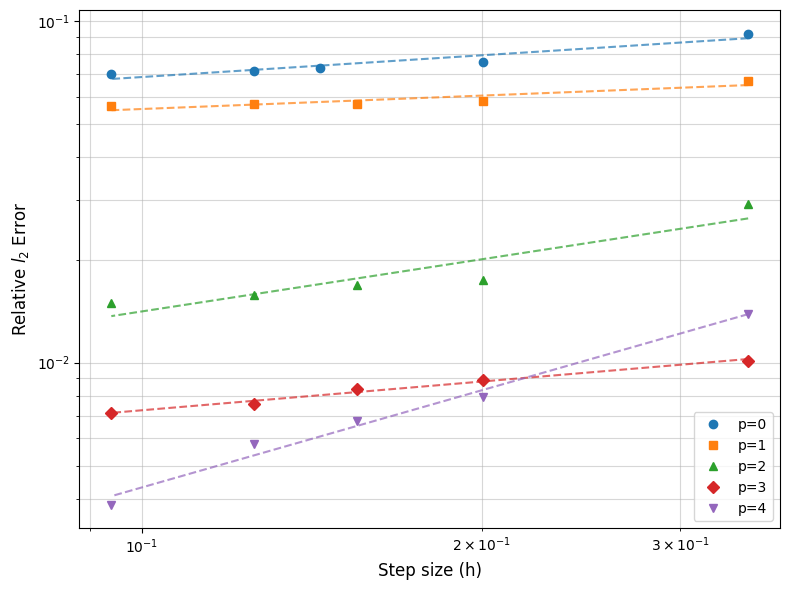

In [8]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = ['p=0', 'p=1', 'p=2', 'p=3','p=4']
plt.figure(figsize=(8, 6))

for i in range(5):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    # plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]} (Slope: {slope:.2f})')
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')

    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)

plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
# plt.title('Convergence Study: Least Squares Fit', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('./result/heat_rfmfd_p=0123_convergence_scatter.eps', bbox_inches='tight')
plt.show()

$Operator learning$

In [9]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve
from scipy.linalg import cholesky, solve_triangular

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)

def wls_chol_rowmax(A, b, reg=0.0):
    """
    WLS_CHOL_ROWMAX
    Solve weighted least squares using Cholesky factorization
        min_x || W (A x - b) ||_2^2
    where weights w_i = 1 / (max_j |A_ij| + eps)
    Parameters
    ----------
    A : scipy.sparse matrix, shape (M, N)
        Sparse system matrix
    b : ndarray, shape (M,)
        Right-hand side
    reg : float, optional
        Tikhonov regularization parameter (default 0)
    Returns
    -------
    x : ndarray, shape (N,)
        Solution vector
    info : dict
        Diagnostic information
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()

    b = np.asarray(b,dtype=np.float64).squeeze(-1) 
    M, N = A.shape
    assert b.shape[0] == M, "Dimension mismatch"
    # -------------------------------------------------
    # Step 1: row-wise max for sparse matrix
    # -------------------------------------------------
    # Equivalent to MATLAB: full(max(abs(A), [], 2))
    # row_max = np.asarray(np.abs(A).max(axis=1)).ravel()   # (M,) ndarray
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    eps0 = 1e-12
    w = 10 / (row_max + eps0)   # (M,)
    # -------------------------------------------------
    # Step 2: apply weights implicitly
    # -------------------------------------------------
    # Aw = W * A, bw = W * b
    W = sp.diags(w, offsets=0, format='csr')
    Aw = W @ A
    bw = w * b
  
    # -------------------------------------------------
    # Step 3: normal equations
    # -------------------------------------------------
    AtA = Aw.T @ Aw    # (N, N), sparse SPD (hopefully)
    Atb = Aw.T @ bw

    if reg > 0:
        AtA = AtA + reg * sp.eye(N, format='csr')

    # -------------------------------------------------
    # Step 4: Cholesky solve
    # -------------------------------------------------
    try:
        # scipy 对稀疏 Cholesky 没有内建 chol
        # spsolve 等价于 MATLAB 的 "\" 退化路径
        x = spla.spsolve(AtA, Atb)
        flag = 0
    except Exception:
        print("Warning: linear solve failed.")
        x = spla.lsmr(AtA, Atb)[0]
        flag = 1
    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    try:
        cond_est = spla.onenormest(AtA) * spla.onenormest(spla.inv(AtA))
    except Exception:
        cond_est = np.nan

    info = {
        "flag": flag,
        "row_max_min": row_max.min(),
        "row_max_max": row_max.max(),
        "cond_est": cond_est
    }
    return x, info

def rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N)) # 按行/按元素赋值效率高
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))

    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    O = np.zeros((Norder,Norder))
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # print(np.max(np.max(Phi_jj)), np.min(np.min(Phi_jj)))
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## AP
        P = poly2D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+3)
        AP[K:,:-Norder] = P.T # (Norder,K)
        AP = AP + reg * np.eye(K+Norder)
        LU = lu_factor(AP)
        ## w_ide, w_lap
        p_y = poly2D_at_point(y, order)  # (Norder,1)
        RHS_ide[:K,0] = phi_xj[:,0]                           # shape (K,)
        RHS_ide[K:,0] = p_y[:,0]
        w_ide = lu_solve(LU, RHS_ide).T # (1,K+Norder)
        # w_ide = np.linalg.solve(AP,RHS_ide).T # (1,K+Norder)
        RHS_lap[:K,0] = lap_phi[:,0]
        RHS_lap[K:,0] = laplacian_poly2D(order, y)[:,0]
        w_lap = lu_solve(LU, RHS_lap).T # (1,K+Noder)
        # w_lap = np.linalg.solve(AP,RHS_lap).T # (1,K+Noder)
        if i < M1 :
            LBDF1[i:i+1,idx_local] += (w_ide[0:1,:K] - tau * w_lap[0:1,:K])
            LBDF2[i:i+1,idx_local] += (3 * w_ide[0:1,:K] - 2* tau * w_lap[0:1,:K])
        else:
            LBDF1[i:i+1,idx_local] += w_ide[0:1,:K]
            LBDF2[i:i+1,idx_local] += w_ide[0:1,:K]
        LI[i:i+1,idx_local] += w_ide[0:1,:K]
        
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    U = np.zeros((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr() # 高效矩阵乘法、解线性系统
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M is not equal to N. Please use QR.")
        # ===========================================================
        # M != N : BDF2 + row-max weighted least squares (Cholesky)
        # ===========================================================
        # ---------- BDF1 start ----------
        # alpha_0 已由初值隐式给定：LI * alpha_0 = u0
        reg1 = reg
        alpha_0, info = wls_chol_rowmax(LI, u0, reg)
        print("LI's condition numbers is ", np.sqrt(info["cond_est"]))
        alpha_0 = alpha_0.reshape(-1, 1)
        # print(alpha_0.shape)
        
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]
        RHS = np.vstack([rhs_int, g_val[:, 1:2]])

        alpha_1, _ = wls_chol_rowmax(LBDF1, RHS, reg)
        alpha_1 = alpha_1.reshape(-1, 1)

        U[:M1, 1:2] = LI[:M1, :] @ alpha_1
        U[M1:, 1:2] = g_val[:, 1:2]

        # ---------- fixed row weights from LBDF2 ----------
        row_max = np.abs(LBDF2).max(axis=1).toarray().ravel()
        row_max[row_max == 0.0] = 1.0
        w = 10 / ((row_max + 1e-12) ** 2) # reg = 1e-12
        W = sp.diags(w, offsets=0, shape=(M, M), format="csr")

        # ---------- normal matrix and Cholesky ----------
        AtWA = LBDF2.T @ (W @ LBDF2)
        cond_AtWA_est = spla.onenormest(AtWA) * spla.onenormest(spla.inv(AtWA))
        print("LBDF2's condition numbers is ", np.sqrt(cond_AtWA_est))
        if reg1 > 0:
            AtWA = AtWA + reg1 * sp.eye(N, format="csr")

        # dense Cholesky
        R = cholesky(AtWA.toarray(), lower=False)
        # ---------- BDF2 time stepping ----------
        for i in range(1, NT - 1):
            rhs_int = LI[:M1, :] @ (4 * alpha_1 - alpha_0) \
                      + 2 * tau * f_val[:, i+1:i+2]

            RHS = np.vstack([rhs_int, g_val[:, i+1:i+2]])
            AtWb = LBDF2.T @ (W @ RHS)

            # solve (R^T R) alpha = AtWb
            y = solve_triangular(R.T, AtWb, lower=True)
            alpha_2 = solve_triangular(R, y, lower=False)

            U[:M1, i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:, i+1:i+2] = g_val[:, i+1:i+2]

            alpha_0 = alpha_1
            alpha_1 = alpha_2


    return U,LBDF1,LBDF2,LI


#还得改成每次求解多个方程的情况



class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(0.9225)**2 * x**2) # operator
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, -0, 0)

M is not equal to N. Please use QR.
LI's condition numbers is  620.9414952034131
LBDF2's condition numbers is  588.1121394085288
p = 3; L infity error in u_rfmfd: 9.042e-02
p = 3; Relative L2 error in u_rfmfd: 5.675e-03
p = 3; Relative L2 error at T time of u_rfmfd: 1.814e-03
Time step 0, Relative L2 error: 8.813e-18
Time step 1, Relative L2 error: 1.454e-02
Time step 2, Relative L2 error: 1.413e-02
Time step 3, Relative L2 error: 1.405e-02
Time step 4, Relative L2 error: 1.395e-02
Time step 5, Relative L2 error: 1.378e-02
Time step 6, Relative L2 error: 1.356e-02
Time step 7, Relative L2 error: 1.332e-02
Time step 8, Relative L2 error: 1.307e-02
Time step 9, Relative L2 error: 1.280e-02
Time step 10, Relative L2 error: 1.252e-02
Time step 11, Relative L2 error: 1.224e-02
Time step 12, Relative L2 error: 1.195e-02
Time step 13, Relative L2 error: 1.166e-02
Time step 14, Relative L2 error: 1.136e-02
Time step 15, Relative L2 error: 1.108e-02
Time step 16, Relative L2 error: 1.079e-02
Ti

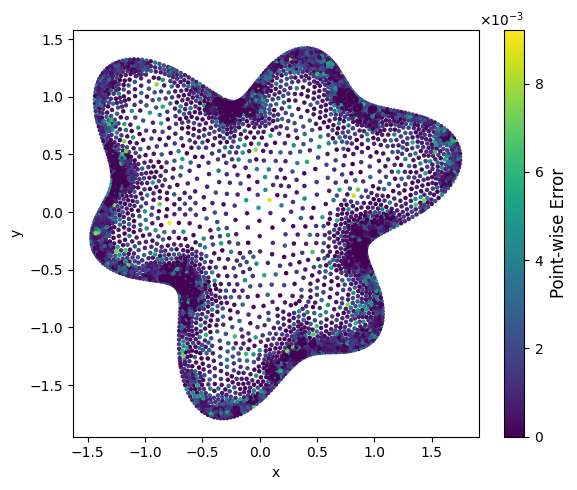

In [19]:
import matplotlib.ticker as ticker

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
# u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)



tau = 1e-3
T = 2e-1

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

# data = loadmat('./data/mydata_heat_pdetool_4029_T2e-2_tau1e-4.mat') # order = 3; K = 150

data = loadmat('./data/mydata_heat_pdetool_4029_T2e-1_tau1e-3.mat') # order = 3; K = 150


#'u0_0', 'uT_0', 'U0_new',  'UT_new', 'p','in','bc'
# (M,1), (M,NT),  (M,100), (100,M,NT)
p,u0_0,uT_0, U0_new, UT_new, index_in,index_bc = data['p'],data['u0_0'],data['uT_0'],data['U0_new'],data['UT_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print("UT_new.shape,", UT_new.shape) # (n_batch,M,NT)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2

U0_new = np.concatenate([U0_new[index_in,:],U0_new[index_bc,:]],axis=0)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
u0_func = U0_new[:,testnum]  # (M,)

order = 3
# K = 150

reg = 1e-12
u_true = UT_new[testnum,:,:]
# print(u_true.shape) # (M,NT)
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
# print(u_true.shape) # print(u_true.shape) # (M,NT)

# #===========================================================
# #==================== Source points X ====================
# #===========================================================
X = p
# N_patch_grid = 5
# N_local_per_patch = 200
# N_boundary = 200

K = 150
N_patch_grid = 6
N_local_per_patch = 50
N_boundary = 100


R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])

# # ===========================================================

if order == 0:
    UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)

# print("U.shape ",U.shape) #(M,NT)
error = np.abs(U- u_true)
error = np.max(np.max(error))

print(f'p = {order}; L infity error in u_rfmfd: {error:.3e}')
error_u = relative_l2(U.ravel(), u_true.ravel())
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u:.3e}')

error_u = relative_l2(U[:,-1:], u_true[:,-1:])
print(f'p = {order}; Relative L2 error at T time of u_rfmfd: {error_u:.3e}')

e = np.abs(U[:,-1].ravel() - u_true[:,-1].ravel())
e =np.asarray(e)

for i in range(Nt):
    err_time = relative_l2(U[:,i], u_true[:,i])
    print(f'Time step {i}, Relative L2 error: {err_time:.3e}')

plt.figure(figsize=(6,5))
print(Y[:,0].shape, Y[:,1].shape, e.shape)
sc = plt.scatter(Y[:,0], Y[:,1], c = e, cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()



In [11]:
def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    """

    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)

    W = sp.diags(w, format='csr')

    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)

        if x.ndim == 1:
            x = x[:, None]

        return x

    return solve

def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[0]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin[:, 0:1], Yin[:, 1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:, 0:1], Yb[:, 1:2], t) if callable(g_func) else g_func

    u0 = u0_func(Y[:, 0:1], Y[:, 1:2]) if callable(u0_func) else u0_func
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    if u0.ndim == 1:
        u0 = u0[:, None]

    n_batch = u0.shape[1]

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.T
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            rhs = rhs_int[:M1, :] + tau * f_val[:, i + 1:i + 2]

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1, _ = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_val[:, i + 1:i + 2]
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U

    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")

UT_new.shape  (100, 4029, 201)
After reordering, U0_new.shape  (4029, 100)
p = 3, inference time: 16.4215 秒
error_L2.shape: (100, 1), error_inf.shape: (100, 4029, 201)
p = 3, test on 100 samples. The mean of max error: 9.634379e-02, and mean of relative L2 error: 6.196759e-03
p = 3, test on 100 samples. The variance of max error: 2.161998e-04, and variance of relative L2 error: 9.983674e-07


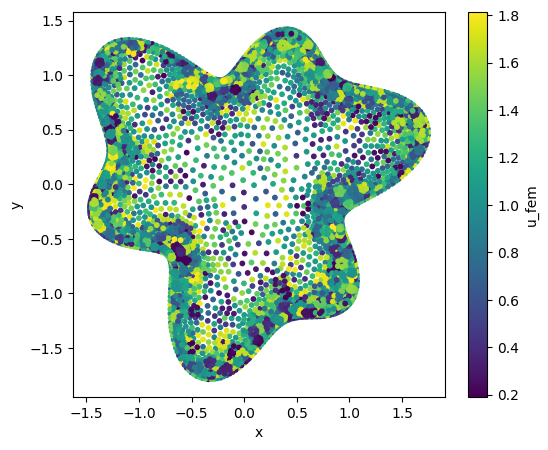

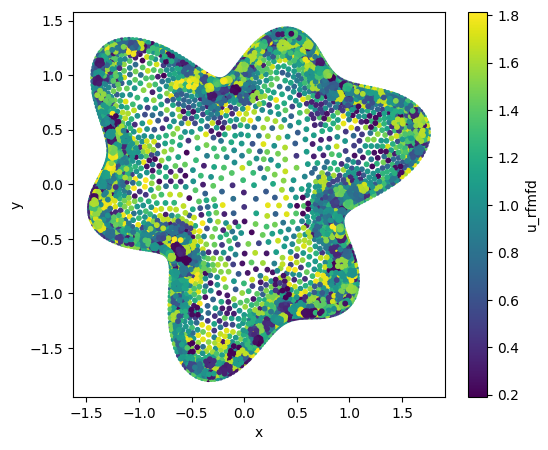

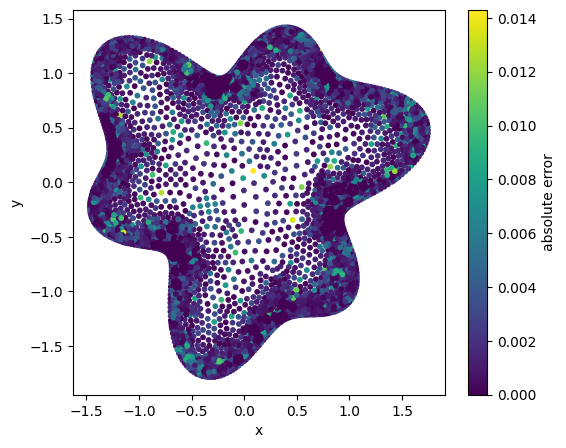

In [15]:
import time

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points


u_true = UT_new # (100,M,NT)
print( "UT_new.shape ", u_true.shape) 
u_true = np.concatenate([u_true[:,index_in,:],u_true[:,index_bc,:]], axis=1)

print("After reordering, U0_new.shape ", U0_new.shape) #(M,100)


start_time = time.time()
UY = test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, U0_new,
                Yin, Yb, t, tau,
                scheme="BDF2") 
# UY =  np.transpose(UY, (2, 0, 1)) # (n_batch, M, NT)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")


error_inf = np.abs(UY - u_true) # (n_batch, M, NT)
E_inf =  np.max(np.max(error_inf, axis=2), axis=1) # (n_batch, 1)
error_L2 = (np.linalg.norm(UY - u_true, axis=(1,2)) / np.linalg.norm(u_true, axis=(1,2)))[:, None] # (n_batch, 1)
print(f"error_L2.shape: {error_L2.shape}, error_inf.shape: {error_inf.shape}") #(n_batch,1), (n_batch,M,NT)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

np.random.seed(30)
q = np.random.randint(0, 100)
u_true_q = u_true[q,:,-1]
UY_q = UY[q,:,-1]
error_inf_q = error_inf[q,:,-1]


plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true_q, cmap='viridis', s=10)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_u_fem_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY_q, cmap='viridis', s=10)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_UY_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error_inf_q, cmap='viridis', s=10)
plt.colorbar(label='absolute error')
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_error_one_test_sample.eps', bbox_inches='tight')
plt.show()



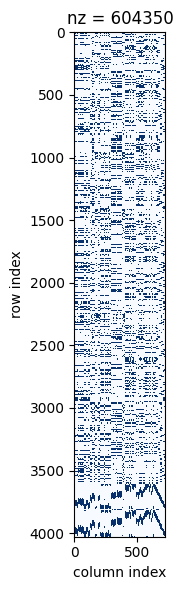

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(LBDF2)

In [14]:
for name, param in Phi.named_parameters():
    print(name, param.data)

input_layer.weight tensor([[ 0.2842],
        [-0.2967],
        [-0.1604],
        [-0.2334],
        [-0.5244],
        [-0.0046],
        [-0.2725],
        [ 0.2287],
        [-0.2161],
        [-0.0757],
        [-0.0685],
        [ 0.0640],
        [ 0.3066],
        [ 0.3625],
        [-0.0834],
        [ 0.0658],
        [ 0.3209],
        [-0.0518],
        [-0.1160],
        [-0.0907],
        [ 0.1197],
        [ 0.0820],
        [-0.0369],
        [ 0.0720],
        [ 0.0468],
        [-0.0157],
        [-0.4444],
        [ 0.1845],
        [-0.0036],
        [ 0.0795],
        [-0.2547],
        [ 0.3697],
        [-0.0387],
        [-0.0531],
        [ 0.0157],
        [-0.1510],
        [ 0.3340],
        [-0.0718],
        [ 0.1586],
        [-0.2193],
        [ 0.1426],
        [-0.0696],
        [ 0.3045],
        [ 0.1889],
        [-0.2389],
        [ 0.2154],
        [-0.2263],
        [-0.0997],
        [ 0.0391],
        [-0.2642]], device='cuda:1', dtype=torch.f